<a href="https://colab.research.google.com/github/Madathanapalleleena/ML_LAB_Practice/blob/main/mlint2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# 1_dt_vs_rf.py
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

data= load_breast_cancer()
X,y=data.data,data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.3)

# Single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_dt = dt.predict(X_test)

print("Decision Tree")
print(classification_report(y_test, y_dt, digits=3))

# Random Forest with different numbers of trees
for n in [1, 5, 10, 50, 100]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_rf = rf.predict(X_test)
    print(f"RandomForest (n_estimators={n}):",
          "acc={:.3f}".format(accuracy_score(y_test, y_rf)),
          "prec={:.3f}".format(precision_score(y_test, y_rf)),
          "rec={:.3f}".format(recall_score(y_test, y_rf)),
          "f1={:.3f}".format(f1_score(y_test, y_rf)))


Decision Tree
              precision    recall  f1-score   support

           0      0.891     0.891     0.891        64
           1      0.935     0.935     0.935       107

    accuracy                          0.918       171
   macro avg      0.913     0.913     0.913       171
weighted avg      0.918     0.918     0.918       171

RandomForest (n_estimators=1): acc=0.912 prec=0.934 rec=0.925 f1=0.930
RandomForest (n_estimators=5): acc=0.936 prec=0.944 rec=0.953 f1=0.949
RandomForest (n_estimators=10): acc=0.930 prec=0.952 rec=0.935 f1=0.943
RandomForest (n_estimators=50): acc=0.924 prec=0.943 rec=0.935 f1=0.939
RandomForest (n_estimators=100): acc=0.936 prec=0.944 rec=0.953 f1=0.949


In [12]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('dt', DecisionTreeClassifier()),
    ('knn', KNeighborsClassifier())
]

for name, m in models:
    m.fit(X_train, y_train)

# --- Max Voting ---
preds = np.vstack([m.predict(X_test) for _, m in models])
print(preds)
max_vote = np.squeeze(mode(preds, axis=0, keepdims=True).mode)
print("Max Voting Acc:", accuracy_score(y_test, max_vote))

# --- Average Voting ---
probs = np.mean(np.vstack([m.predict_proba(X_test)[:, 1] for _, m in models]), axis=0)
avg_vote = (probs >= 0.5).astype(int)
print("Average Voting Acc:", accuracy_score(y_test, avg_vote))

# --- Weighted Average Voting ---
weights = []
for _, m in models:
    p = accuracy_score(y_test, m.predict(X_test))
    weights.append(p)
weights = np.array(weights) / np.sum(weights)

weighted_probs = np.average(
    np.vstack([m.predict_proba(X_test)[:, 1] for _, m in models]),
    axis=0,
    weights=weights
)
weighted_vote = (weighted_probs >= 0.5).astype(int)
print("Weighted Average Voting Acc:", accuracy_score(y_test, weighted_vote))


[[1 0 1 1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1
  1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 0 1 1 1 1 1
  1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 0 0 1 0 1 0 0 0 1 1 0 1 1
  0 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1]
 [1 0 0 1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1
  0 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 0 0 1 1 1 1
  1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 1 1
  0 1 0 0 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1]
 [1 0 1 1 1 0 0 0 0 1 1 1 0 0 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1
  1 1 0 1 0 1 0 1 0 1 0 1 0 1 1 1 1 0 1 0 1 0 0 0 1 0 1 0 1 1 0 1 1 1 1 1
  1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 1 0 1 1
  0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1]]
Max Voting Acc: 0.951048951048951
Average Voting Acc: 0.951048951048951
Weighted Average Voting Acc: 0.95104895104

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# 3_voting_classifiers.py
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data= load_breast_cancer()
X,y=data.data,data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
knn = KNeighborsClassifier()

hard = VotingClassifier(estimators=[('lr', lr), ('dt', dt), ('knn', knn)], voting='hard')
soft = VotingClassifier(estimators=[('lr', lr), ('dt', dt), ('knn', knn)], voting='soft')  # uses predict_proba

hard.fit(X_train, y_train)
soft.fit(X_train, y_train)

print("Hard Voting Acc:", accuracy_score(y_test, hard.predict(X_test)))
print("Soft Voting Acc:", accuracy_score(y_test, soft.predict(X_test)))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Hard Voting Acc: 0.951048951048951
Soft Voting Acc: 0.951048951048951


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
# 4_rf_regressor_oob_real.py
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Load real-world regression dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Regressor with OOB score enabled
rf = RandomForestRegressor(
    n_estimators=100,
    oob_score=True,   # Out-of-Bag evaluation
    random_state=42,
    n_jobs=-1
)

# Train the model
rf.fit(X_train, y_train)

# Predictions
pred = rf.predict(X_test)

# Evaluation metrics
print("Test R² Score:", r2_score(y_test, pred))
print("Test MSE:", mean_squared_error(y_test, pred))
print("OOB R² (Out-of-Bag Score):", rf.oob_score_)


Test R² Score: 0.8051230593157366
Test MSE: 0.2553684927247781
OOB R² (Out-of-Bag Score): 0.8074158009726365


In [15]:
# 5_adaboost_breast_cancer.py
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load binary classification dataset
X, y = load_breast_cancer(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42, test_size=0.3
)

# Initialize AdaBoost
adb = AdaBoostClassifier(
    n_estimators=50,       # number of weak learners
    learning_rate=1.0,     # step size
    random_state=42
)

# Train model
adb.fit(X_train, y_train)

# Predictions & Report
y_pred = adb.predict(X_test)
print("=== AdaBoost on Breast Cancer Dataset ===")
print(classification_report(y_test, y_pred, digits=3))


=== AdaBoost on Breast Cancer Dataset ===
              precision    recall  f1-score   support

           0      0.983     0.906     0.943        64
           1      0.946     0.991     0.968       107

    accuracy                          0.959       171
   macro avg      0.965     0.948     0.956       171
weighted avg      0.960     0.959     0.959       171



Unique clusters (including noise=-1): {np.int64(0), np.int64(1)}


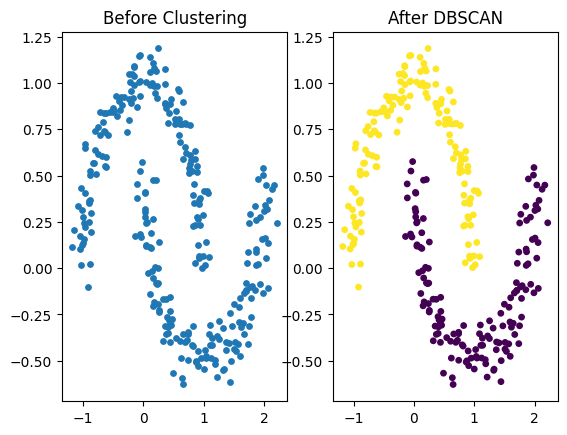

In [17]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Create data
X, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

# --- Before clustering ---
plt.subplot(1, 2, 1)
plt.title("Before Clustering")
plt.scatter(X[:, 0], X[:, 1], s=15)

# --- Apply DBSCAN ---
db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_
print("Unique clusters (including noise=-1):", set(labels))

# --- After clustering ---
plt.subplot(1, 2, 2)
plt.title("After DBSCAN")
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=15)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Unique clusters: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)}


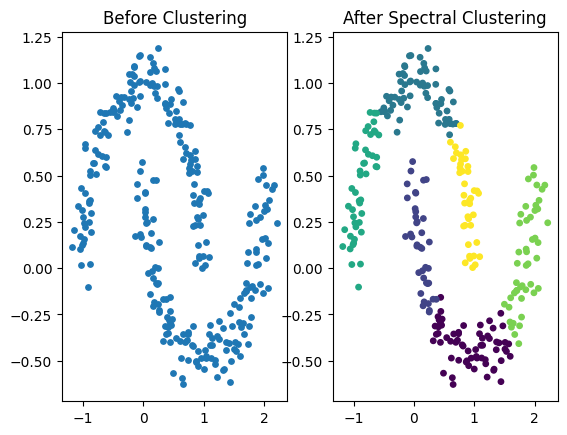

In [23]:
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.datasets import make_moons

# --- Create data ---
X, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

# --- Before clustering ---
plt.subplot(1, 2, 1)
plt.title("Before Clustering")
plt.scatter(X[:, 0], X[:, 1], s=15)

# --- Apply Spectral Clustering ---
sc = SpectralClustering(n_clusters=6, affinity='nearest_neighbors', random_state=42)
labels = sc.fit_predict(X)
print("Unique clusters:", set(labels))

# --- After clustering ---
plt.subplot(1, 2, 2)
plt.title("After Spectral Clustering")
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=15)
plt.show()


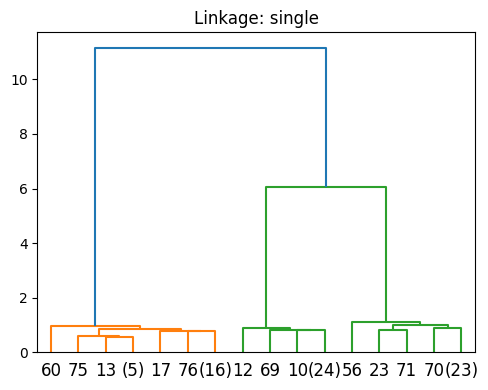

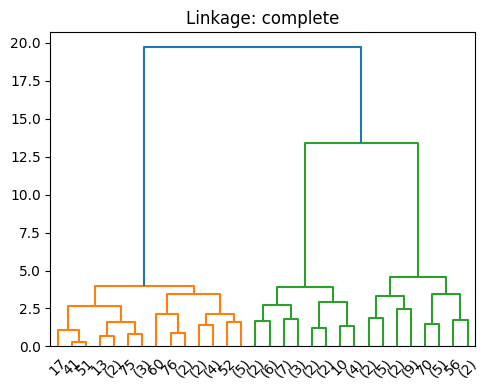

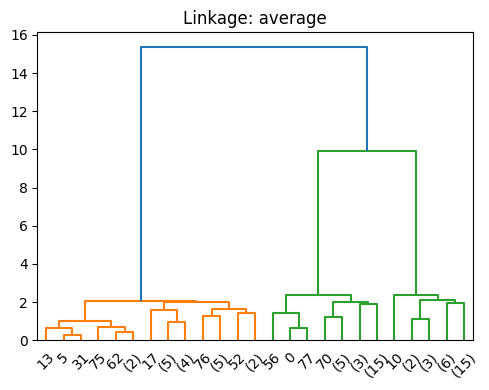

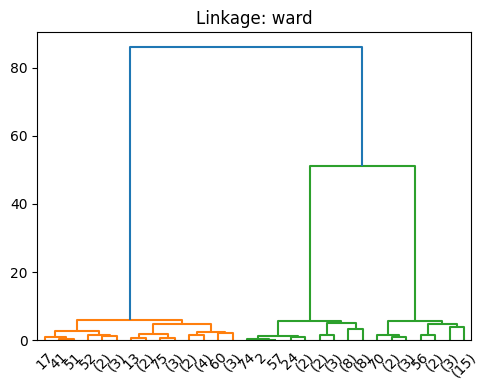

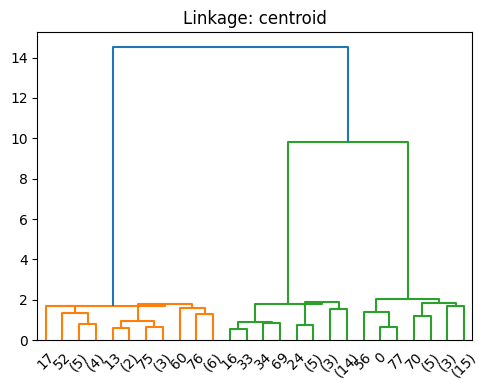

In [25]:
# 9_linkages.py
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=80, centers=3, random_state=42)

methods = ['single','complete','average','ward','centroid']
for m in methods:
    Z = linkage(X, method=m)
    plt.figure(figsize=(5,4))
    dendrogram(Z, truncate_mode='level', p=4)
    plt.title(f'Linkage: {m}')
    plt.tight_layout()
plt.show()


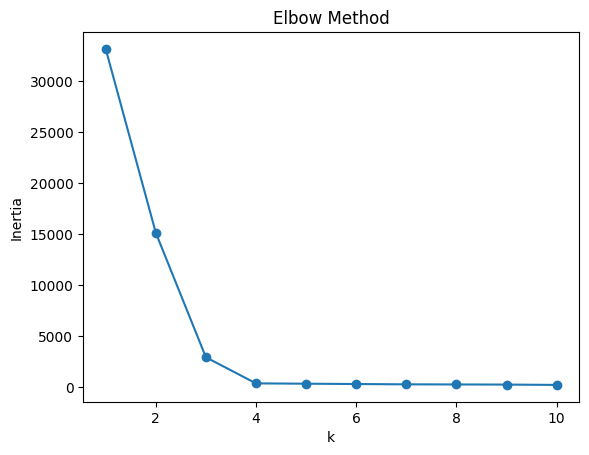

In [26]:
# 6_kmeans_elbow.py
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import numpy as np

X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.6, random_state=42)

inertias = []
ks = range(1, 11)
for k in ks:
    inertias.append(KMeans(n_clusters=k, random_state=42).fit(X).inertia_)

plt.plot(ks, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# run KMeans with chosen k
k = 4
km = KMeans(n_clusters=k, random_state=42).fit(X)
labels = km.labels_


In [32]:
# 7_distance_measures.py
import numpy as np
from scipy.spatial.distance import minkowski, cosine
from scipy.spatial.distance import cityblock, euclidean

def euclidean_dist(a,b): return np.linalg.norm(a-b)
def manhattan_dist(a,b): return np.sum(np.abs(a-b))
def cosine_sim(a,b): return 1 - cosine(a,b)  # returns similarity
def minkowski_dist(a,b,p=3): return minkowski(a,b,p)
def jaccard_index_binary(a,b):
    # expects binary 0/1 arrays
    a = np.asarray(a).astype(bool)
    b = np.asarray(b).astype(bool)
    inter = np.logical_and(a,b).sum()
    union = np.logical_or(a,b).sum()
    return inter/union if union!=0 else 1.0

# Example
a = np.array([1,2,3])
b = np.array([2,2,3])
print("euclid", euclidean_dist(a,b))
print("manhattan", manhattan_dist(a,b))
print("cosine_sim", cosine_sim(a,b))
print("minkowski(p=3)", minkowski_dist(a,b,3))
print("jaccard( binary ):", jaccard_index_binary([1,0,1],[1,1,0]))


euclid 1.0
manhattan 1
cosine_sim 0.9723055853282466
minkowski(p=3) 1.0
jaccard( binary ): 0.3333333333333333


In [27]:
import numpy as np

def perceptron(X, y, lr=0.1, epochs=10):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(Xb.shape[1])
    for _ in range(epochs):
        for xi, yi in zip(Xb, y):
            pred = 1 if np.dot(w, xi) >= 0 else 0
            w += lr * (yi - pred) * xi
    return w

X = np.array([[0,0],[0,1],[1,0],[1,1]])
AND, OR, XOR = [0,0,0,1], [0,1,1,1], [0,1,1,0]

print("AND:", [(x, int(np.dot(perceptron(X, AND), [1,*x])>=0)) for x in X])
print("OR :", [(x, int(np.dot(perceptron(X, OR), [1,*x])>=0)) for x in X])
print("XOR:", [(x, int(np.dot(perceptron(X, XOR), [1,*x])>=0)) for x in X])  # Fails (non-linear)


AND: [(array([0, 0]), 0), (array([0, 1]), 0), (array([1, 0]), 0), (array([1, 1]), 1)]
OR : [(array([0, 0]), 0), (array([0, 1]), 1), (array([1, 0]), 1), (array([1, 1]), 1)]
XOR: [(array([0, 0]), 1), (array([0, 1]), 1), (array([1, 0]), 0), (array([1, 1]), 0)]


In [28]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=500, n_features=10, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3)

for n in [5, 10, 50]:
    mlp = MLPClassifier(hidden_layer_sizes=(n,), max_iter=500, random_state=42)
    mlp.fit(Xtr, ytr)
    print(f"Neurons={n}, Test Accuracy={mlp.score(Xte, yte):.3f}")


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Neurons=5, Test Accuracy=0.913


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Neurons=10, Test Accuracy=0.920
Neurons=50, Test Accuracy=0.900


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [29]:
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = fetch_openml('mnist_784', version=1, as_frame=False, parser="pandas", return_X_y=True)
y = y.astype(int)
Xtr, Xte, ytr, yte = train_test_split(X/255.0, y, test_size=0.2, random_state=42)

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=20, random_state=42)
mlp.fit(Xtr, ytr)
print("Train Acc:", accuracy_score(ytr, mlp.predict(Xtr)))
print("Test Acc :", accuracy_score(yte, mlp.predict(Xte)))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Train Acc: 0.9979107142857143
Test Acc : 0.9746428571428571


In [30]:
import numpy as np
def step(x): return 1 if x >= 0 else 0

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])
w = np.zeros(3)

for _ in range(10):
    for xi, yi in zip(X, y):
        x = np.hstack(([1], xi))
        pred = step(np.dot(w, x))
        w += 0.1 * (yi - pred) * x

print("Weights:", w)
print("Predictions:", [step(np.dot(w, [1,*xi])) for xi in X])


Weights: [-0.2  0.2  0.1]
Predictions: [0, 0, 0, 1]


In [31]:
import numpy as np

def sigmoid(x): return 1 / (1 + np.exp(-x))
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])
w = np.random.randn(3) * 0.1
lr = 0.5

for _ in range(1000):
    for xi, yi in zip(X, y):
        x = np.hstack(([1], xi))
        z = np.dot(w, x)
        y_pred = sigmoid(z)
        w -= lr * (y_pred - yi) * y_pred * (1 - y_pred) * x

print("Predicted Probabilities:", [sigmoid(np.dot(w, [1,*xi])) for xi in X])
print("Predictions:", [int(sigmoid(np.dot(w, [1,*xi])) >= 0.5) for xi in X])


Predicted Probabilities: [np.float64(0.0008313291256604529), np.float64(0.08121438114038308), np.float64(0.08149705981899935), np.float64(0.904089636178906)]
Predictions: [0, 0, 0, 1]
